In [1]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, PathPatch, Wedge
from matplotlib.text import TextPath
from matplotlib.transforms import Affine2D
from matplotlib.path import Path
import numpy as np

from datetime import datetime
from calendar import monthrange


In [2]:
figsize = 8

In [3]:
def curved_text(ax, text, r, angle_offset=0.0, font_size=1.0, font_prop=None):
    """ Add a curved text to an axis. r is the radius of curvature at the text center, angle offset the angle of the text center (in RADIANS)"""

    # Create a TextPath object with the text
    text_path = TextPath((0, 0), text, size=font_size, prop=font_prop)
    bb = text_path.get_extents()
    # Center the text path
    text_centered = Affine2D().translate(-0.5 * (bb.x0 + bb.x1), -0.5 * (bb.y0 + bb.y1)).transform_path(text_path)

    # Curve the text vertexes
    verts = text_centered.vertices
    new_verts = np.array([((r+y)*np.sin(x/r + angle_offset), (r+y)*np.cos(x/r + angle_offset)) for (x,y) in verts])
    text_centered.vertices = new_verts

    # Create a PathPatch from the curved text path and add it to the axis
    patch = PathPatch(text_centered, color='black', linewidth=0)
    ax.add_patch(patch)

In [4]:

def draw_moon(ax, day, center_xy = (0,0), radius = 1.0, lw=0.1):
    
    (center_x, center_y) = center_xy

    month_length=29.53

    # Phase angle (Sun-Moon-Observer) from 0 (new) to to pi (full) and back
    phase_angle = 2*np.pi * (day / month_length)

    # Circle for the lunar disk
    t = np.linspace(0, 2*np.pi, 100)
    moon_x, moon_y = center_x + radius*np.cos(t), center_y + radius*np.sin(t)

    # Plot a black moon
    ax.fill(moon_x, moon_y, color="black", lw=lw)  
    ax.plot(moon_x, moon_y, color="black", lw=lw)   

    sign = 1 if phase_angle <= np.pi else -1

    # Terminator ellipse (projected shadow line)
    tt = np.linspace(-np.pi/2, np.pi/2, 50)
    x, y = center_x + radius * sign * np.cos(phase_angle) * np.cos(tt), center_y + radius * np.sin(tt)
    limb_x, limb_y = center_x + radius * sign *np.cos(tt), center_y + radius * np.sin(tt)

    # Build illuminated polygon: ellipse arc + limb arc
    # The shape is filled correctly if the points are given in counter-clockwise order
    if phase_angle <= np.pi:  # waxing (right side lit)
        poly_x = np.concatenate([x, limb_x[::-1]])
        poly_y = np.concatenate([y, limb_y[::-1]])
    else:  # waning (left side lit)

        poly_x = np.concatenate([limb_x, x[::-1]])
        poly_y = np.concatenate([limb_y, y[::-1]])

    ax.fill(poly_x, poly_y, color="white", lw=0)   # illuminated part

In [5]:
def circle_index(ax, r_in, r_out, r_cut=0.0, cut_size=0.0, index_angle=np.pi/12, lw=1.2, color='k'):

    t = np.linspace(0, 2*np.pi-index_angle, 100)
    circle_x, circle_y = r_in*np.sin(t), r_in*np.cos(t)
    
    t = np.linspace(2*np.pi - 0.5*index_angle*r_in/r_out, 2*np.pi, 10)

    l = index_angle*r_in/r_out*np.pi

    r = np.linspace(r_out - l, r_out, 10)
    index_x, index_y = r*np.sin(t), r*np.cos(t)

    t_cut = np.linspace(0, np.pi, 50)
    cut_x, cut_y = -0.5*cut_size*np.sin(t_cut), r_cut + 0.5*cut_size*np.cos(t_cut)

    ax.plot(np.concat([circle_x, index_x, cut_x, [0]]), np.concat([circle_y, index_y, cut_y, [r_in]]), lw=lw, color=color)


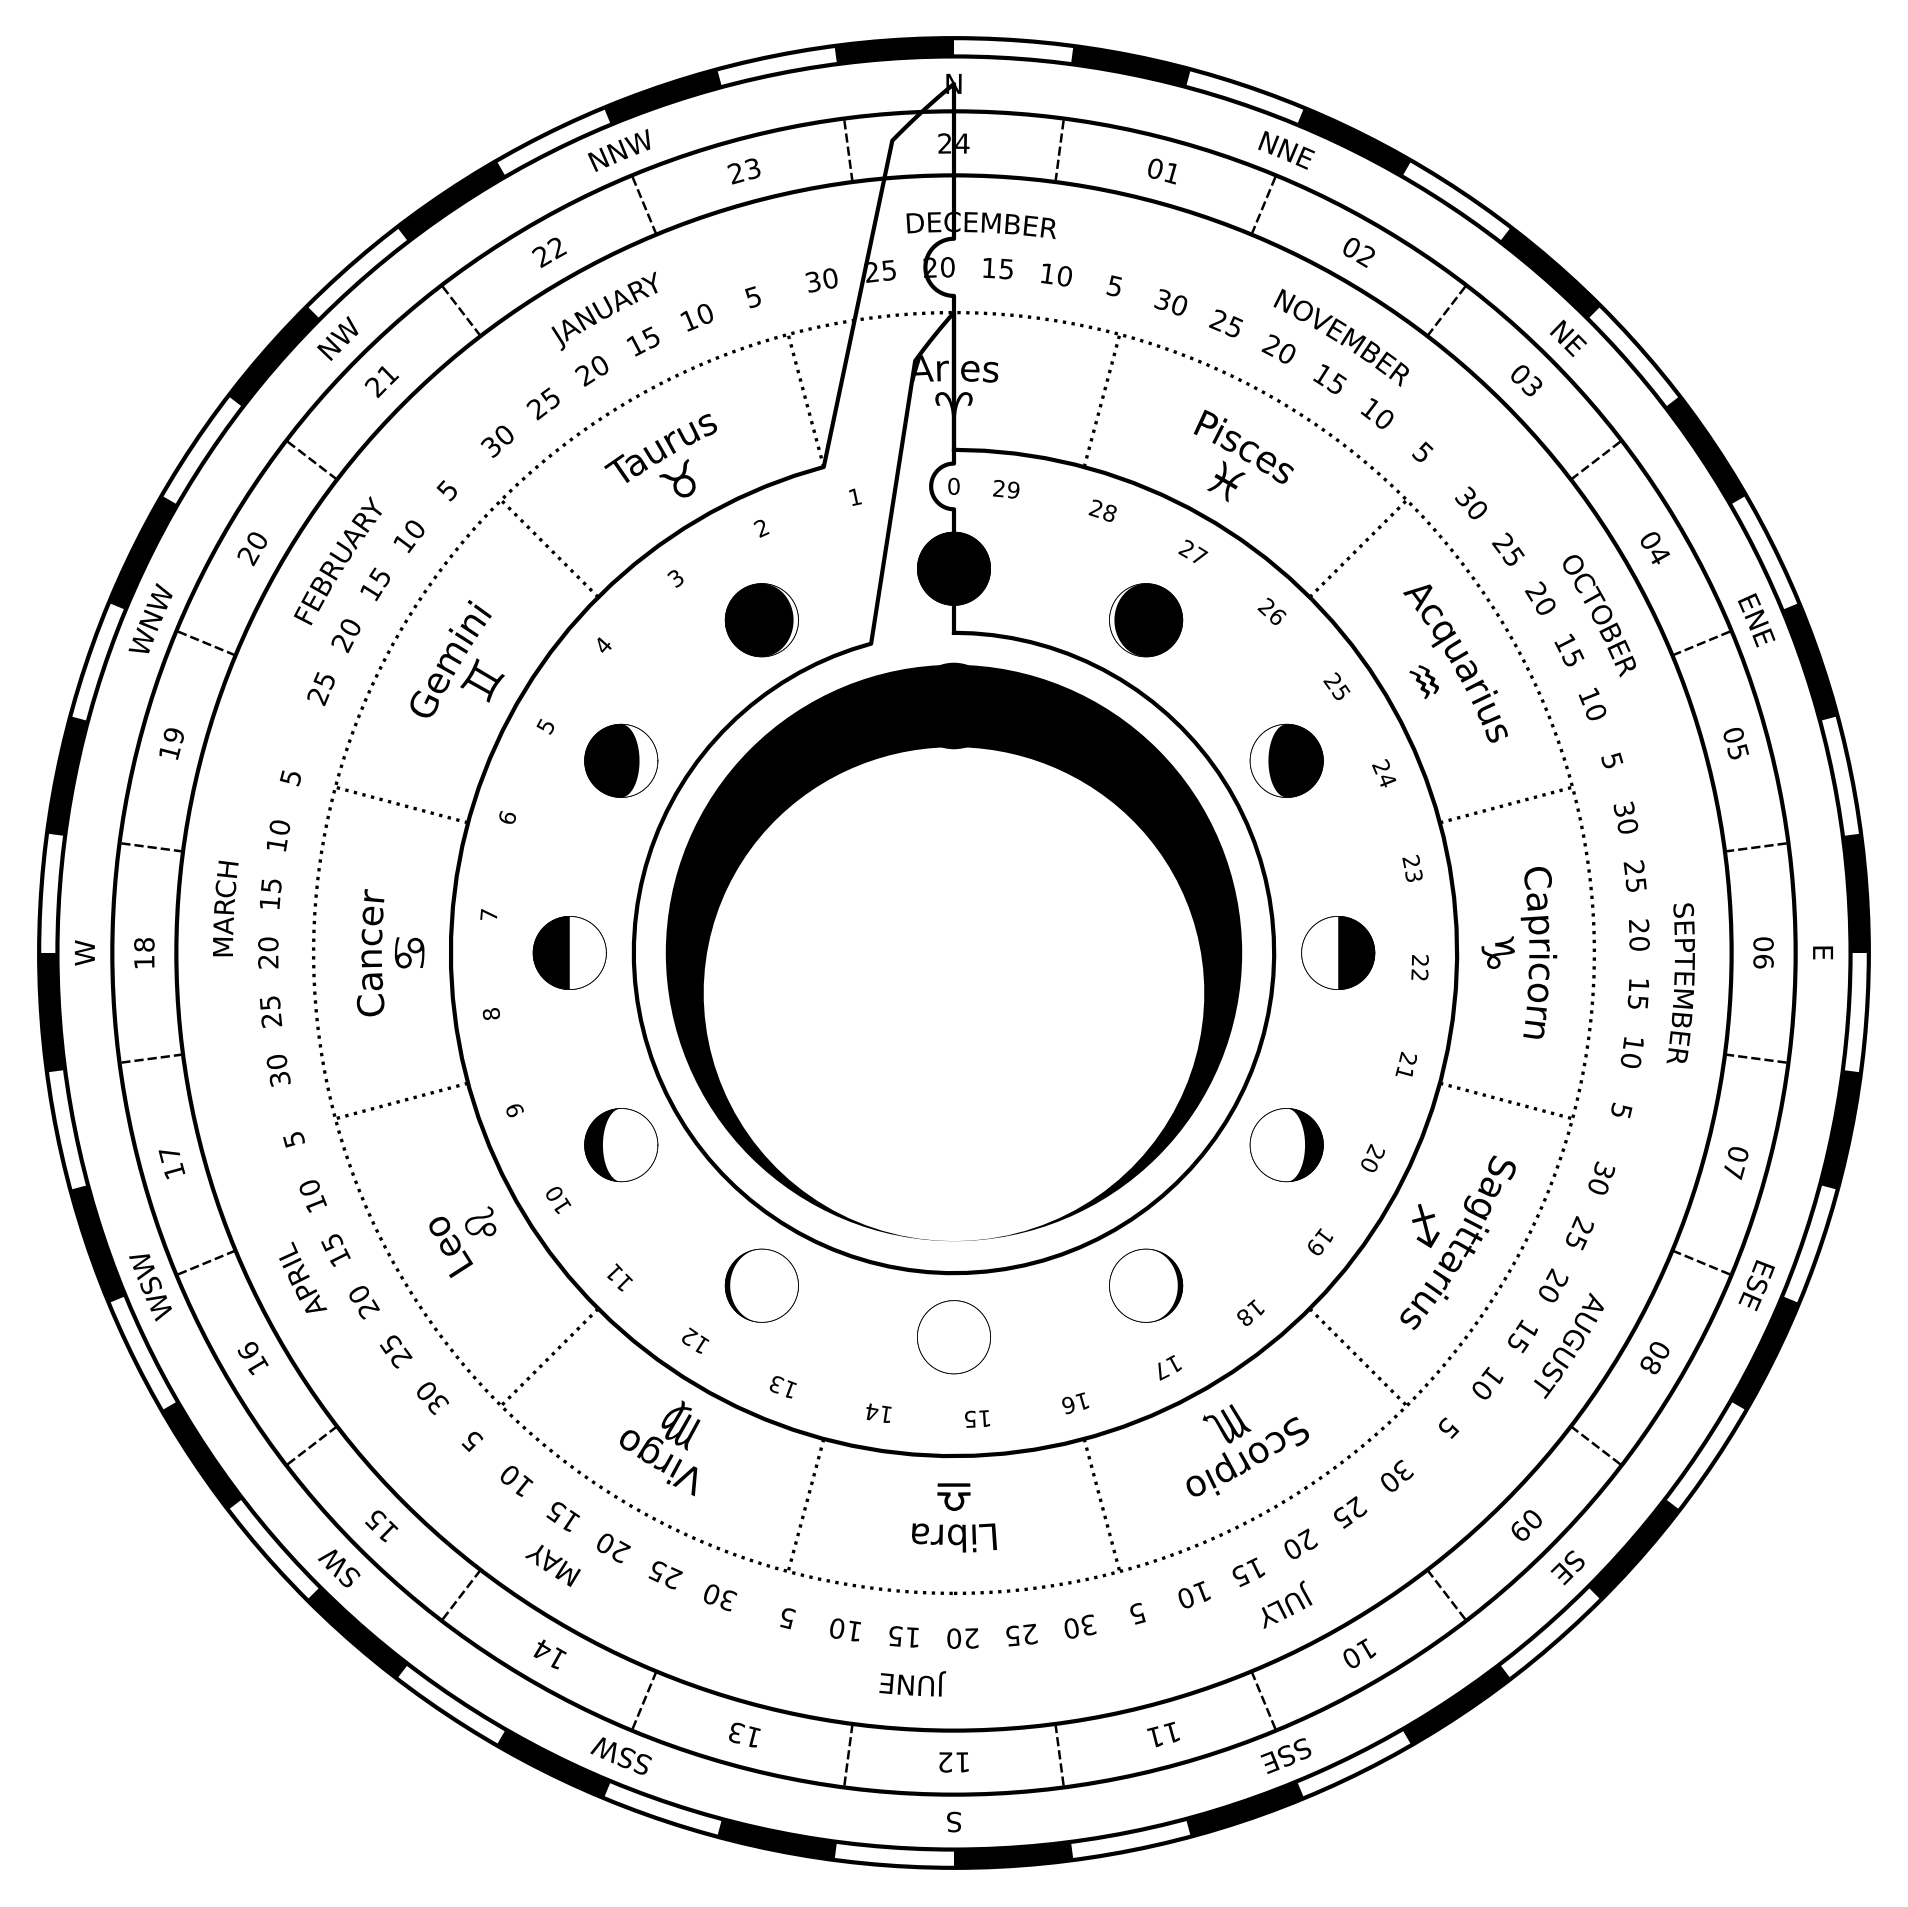

In [34]:
fig, ax = plt.subplots(figsize=(figsize, figsize), dpi=300)
fig.subplots_adjust()

# Radius of the different sections
r_border = figsize
r_compass = 0.98*figsize
r_daytime = 0.92*figsize
r_datetime = 0.85*figsize
r_zodiac = 0.70*figsize
r_sun = 0.55*figsize
r_moon = 0.35*figsize

# Plot border circle
border_circle = Circle((0,0), r_border, facecolor='none', edgecolor='k')
ax.add_patch(border_circle)

# Draw wedges in the compass
n_wedges = 48
for i in range(0, n_wedges, 2):
    ax.add_patch(Wedge(center=(0,0), r= r_border, theta1=i*360/n_wedges, theta2=(i+1)*360/n_wedges, width= r_border-r_compass, facecolor='k', edgecolor='none'))

# Draw compass circle
ax.add_patch(Circle((0,0), r_compass, facecolor='none', edgecolor='k'))

# Plot dirctions labels
directions = ['N', 'NNE', 'NE', 'ENE', 'E', 'ESE', 'SE', 'SSE', 'S', 'SSW', 'SW', 'WSW', 'W', 'WNW', 'NW', 'NNW']
r_directions = r_daytime + (r_compass - r_daytime)*0.5

for d in range(16):
    a = np.pi/8 * d
    curved_text(ax, directions[d], r_directions, angle_offset=a, font_size=figsize*0.03)

# Draw daytime circle
ax.add_patch(Circle((0,0), r_daytime, facecolor='none', edgecolor='k'))

# Plot hours
r_hours = r_datetime + (r_daytime-r_datetime)*0.5

for h in range(1, 25):
    a = np.pi/12 * h
    
    # plot Hours (0-24)
    curved_text(ax, f'{h:02}', r_hours, angle_offset=a, font_size=figsize*0.03)
    # Plot half-hours
    ax.plot((r_datetime*np.sin(a + np.pi/24), r_daytime*np.sin(a + np.pi/24)), (r_datetime*np.cos(a + np.pi/24), r_daytime*np.cos(a + np.pi/24)), ls='--', color='k', lw=0.6)
    
# Plot datetime circle
ax.add_patch(Circle((0,0), r_datetime, facecolor='none', edgecolor='k'))

r_months = r_zodiac + (r_datetime-r_zodiac)*0.66
r_days = r_zodiac + (r_datetime-r_zodiac)*0.33

# Angle of the spring Equinox, which correspond to the 0 RA value, which will be down
equinox_offest = datetime(2001,3,20).timetuple().tm_yday/365

# Plot dates and months
for m in range(1,13):
    days_in_month = monthrange(2001,m)[1]

    # Plot the day label
    for day in range(5,days_in_month+1,5):
        # Get the angle as a fraction of the whole year
        angle = (datetime(2001, m, day).timetuple().tm_yday/365 - equinox_offest)
        a = 2*np.pi*angle + np.pi/2
        curved_text(ax, f'{day}', r_days, angle_offset=-a, font_size=figsize*0.03)

    # Plot the month label
    angle = ((datetime(2001, m, 1).timetuple().tm_yday + days_in_month/2)/365 - equinox_offest)
    a = 2*np.pi*angle + np.pi/2
    month_name = f'{datetime(2001,m,1).strftime('%B').upper()}'
    curved_text(ax, month_name, r_months, angle_offset=-a, font_size=figsize*0.03)

# Plot zodiac ring
ax.add_patch(Circle((0,0), r_zodiac, facecolor='none', edgecolor='k', linestyle=':', lw=0.8))

zodiac_names = ['Aries', 'Taurus', 'Gemini', 'Cancer', 'Leo', 'Virgo', 'Libra', 'Scorpio', 'Sagittarius', 'Capricorn', 'Acquarius', 'Pisces']
zodiac_symbols = ['\u2648', '\u2649', '\u264A', '\u264B', '\u264C', '\u264D','\u264E', '\u264F', '\u2650', '\u2651', '\u2652', '\u2653']

r_zodiac_names = r_sun + (r_zodiac -r_sun)*0.6
r_zodiac_signs = r_sun + (r_zodiac -r_sun)*0.3

# Plot zodiac names and symbols
for i in range(12):
    a = - np.pi/6 * i 
    ax.plot((r_sun*np.sin(a - np.pi/12), r_zodiac*np.sin(a - np.pi/12)), (r_sun*np.cos(a - np.pi/12), r_zodiac*np.cos(a - np.pi/12)), ls=':', color='k', lw=0.8)
    curved_text(ax, f'{zodiac_names[i]}', r=r_zodiac_names, angle_offset=a, font_size=figsize*0.04)
    curved_text(ax, f'{zodiac_symbols[i]}', r=r_zodiac_signs, angle_offset=a, font_size=figsize*0.05)

# Plot sun dial
circle_index(ax, r_in = r_sun, r_out = 0.5*(r_daytime + r_compass), r_cut = r_days, cut_size=0.5, lw=1)

# Plot lunar month days
sinodic_month = 29.53

r_phases = r_moon + (r_sun - r_moon)*0.80

for i in range(0,30):
    a = - 2*np.pi*i/sinodic_month
    curved_text(ax, f'{i}', r_phases, angle_offset=a, font_size=figsize*0.025)

# Plot Lunar phases

n_moons = 12
r_moons = r_moon + (r_sun - r_moon)*0.35
moon_size = (r_sun - r_moon)*0.2

for i in range(n_moons):
    angle = -i *2*np.pi/n_moons
    draw_moon(ax, day = i/n_moons*sinodic_month, center_xy=(r_moons*np.sin(angle), r_moons*np.cos(angle)), radius=moon_size, lw=0.2)

# Plot the cycloid
r_cycloid = 0.9*r_moon
ratio = 5   # ratio between the cyclid inner radius and the moon cutout size
r_in = r_cycloid/(1 + 2/ratio)
r_mask = (r_cycloid - r_in)*0.5


# Draw the lunar cycloid
ax.add_patch(Circle((0,0), radius = r_cycloid, facecolor='k', edgecolor='none'))
theta = np.linspace(0, 2*np.pi, 101)
r_cycloid = r_in - r_mask*(np.cos(theta) - 1)
ax.fill(r_cycloid*np.sin(theta), r_cycloid*np.cos(theta), color='w', lw=0)


'''
for i in range(8):
    x, y = (r_in + r_mask)*np.sin(i*np.pi/4), (r_in + r_mask)*np.cos(i*np.pi/4)
    ax.add_patch(Circle((x,y), r_mask, facecolor='none', edgecolor='orange'))
'''



# Plot the moon dial
circle_index(ax, r_moon, r_out=r_zodiac, r_cut = r_phases, cut_size=0.4, lw=1)

# Plot the cycloid cutout
ax.add_patch(Circle((0, r_in + r_mask), r_mask, facecolor='none', edgecolor='k'))
    
ax.set_xlim(-1.01*figsize,1.01*figsize)
ax.set_ylim(-1.01*figsize,1.01*figsize)
ax.set_aspect('equal')
ax.set_axis_off()

plt.show()

In [14]:
np.concatenate(arrays = [[0], [1], *([2],[3])])




TypeError: concatenate() got an unexpected keyword argument 'arrays'